In [3]:
import cv2
import matplotlib.pyplot as plt

In [26]:
def caracterizar_video(caminho_video):
    # Inicializa a captura do vídeo
    cap = cv2.VideoCapture(caminho_video)

    if not cap.isOpened():
        print(f"Erro: Não foi possível abrir o vídeo {caminho_video}")
        return

    # Extração de propriedades nativas do OpenCV
    fps = cap.get(cv2.CAP_PROP_FPS)
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    largura = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    altura = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

    # Decodificação básica do Codec (FOURCC)
    codec_int = int(cap.get(cv2.CAP_PROP_FOURCC))
    codec_str = "".join([chr((codec_int >> 8 * i) & 0xFF) for i in range(4)])

    # Cálculo da duração
    duracao_segundos = total_frames / fps if fps > 0 else 0

    # Formatação de saída
    print("=== Caracterização da Entrada (Baseline) ===")
    print(f"Arquivo: {caminho_video}")
    print(f"Resolução: {largura}x{altura}")
    print(f"FPS: {fps:.2f}")
    print(f"Total de Frames: {total_frames}")
    print(f"Duração: {duracao_segundos:.2f} segundos")
    print(f"Codec (FOURCC): {codec_str}")

    cap.release()

In [24]:
def visualizar_frames_ground_truth(caminho_video, indices_frames):
    """
    Extrai e exibe frames específicos de um vídeo num Jupyter Notebook.
    """
    cap = cv2.VideoCapture(caminho_video)

    indices_frames = indices_frames if isinstance(indices_frames, list) else [indices_frames]
    if not cap.isOpened():
        print("Erro ao abrir o vídeo.")
        return

    # Define o tamanho da figura dinamicamente baseado na quantidade de frames
    num_frames = len(indices_frames)
    fig, axes = plt.subplots(1, num_frames, figsize=(4 * num_frames, 4))

    # Garante que 'axes' seja iterável mesmo se houver apenas 1 frame no array
    if num_frames == 1:
        axes = [axes]

    for ax, idx in zip(axes, indices_frames):
        # Move o ponteiro do decodificador de vídeo direto para o frame desejado
        cap.set(cv2.CAP_PROP_POS_FRAMES, idx)
        sucesso, frame = cap.read()

        if sucesso:
            # OpenCV carrega as imagens no padrão BGR.
            # O Matplotlib exige RGB para plotar as cores corretamente.
            frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

            ax.imshow(frame_rgb)
            ax.set_title(f"Corte no Frame: {idx}", fontsize=12)
            ax.axis('off') # Remove os eixos (réguas) para focar na imagem
        else:
            ax.set_title(f"Falha ao ler frame {idx}")
            ax.axis('off')

    plt.tight_layout()
    plt.show()

    # Libera o arquivo da memória
    cap.release()

### Minecraft Trailer

In [25]:
caracterizar_video("data/videos/minecraft_trailer.mp4")

=== Caracterização da Entrada (Baseline) ===
Arquivo: data/videos/minecraft_trailer.mp4
Resolução: 854x480 (979.65 pixels diagonais)
FPS: 23.98
Total de Frames: 1439
Duração: 60.02 segundos
Codec (FOURCC): h264


In [21]:
with open("manual/minecraft_trailer.txt", "r") as f:
    indices_frames_minecraft = list(map(int, f.read().strip().split(',')))

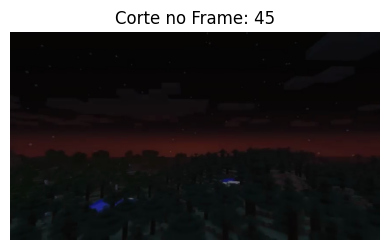

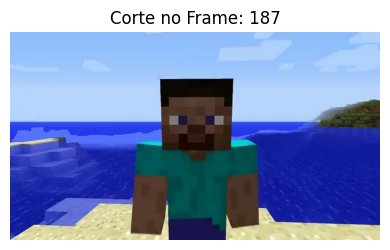

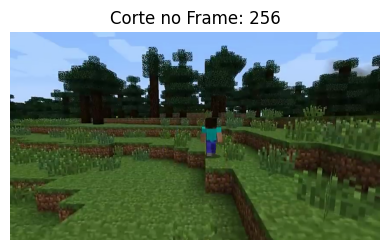

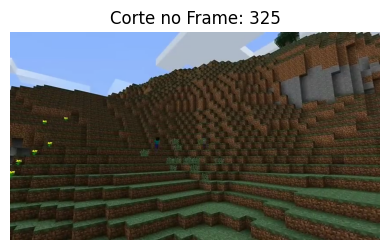

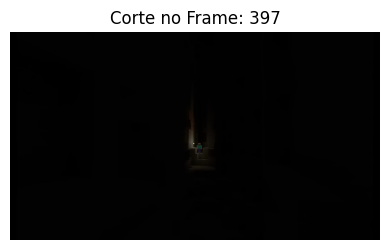

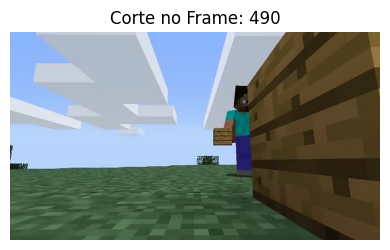

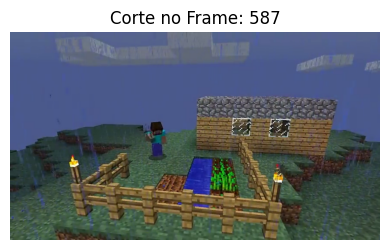

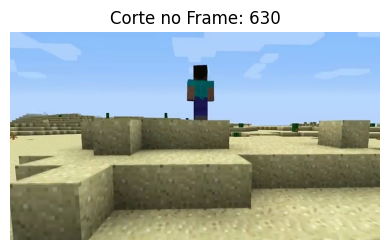

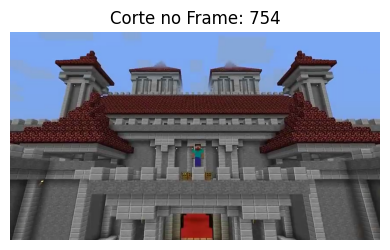

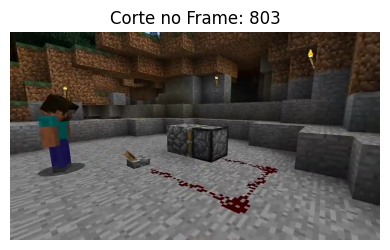

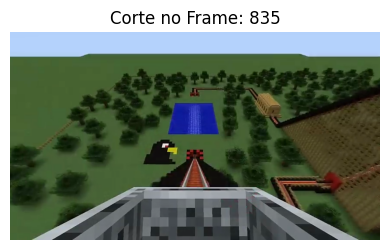

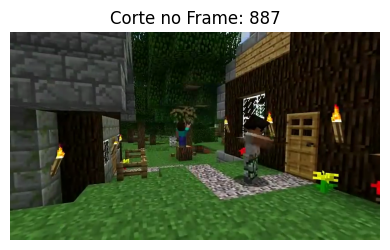

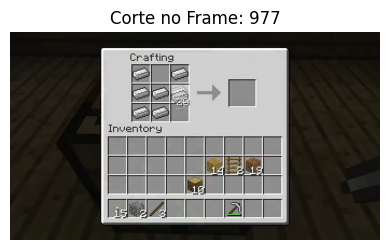

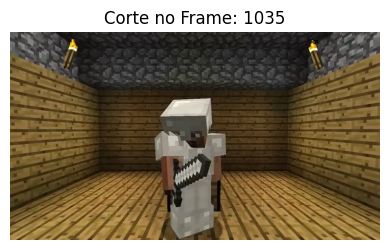

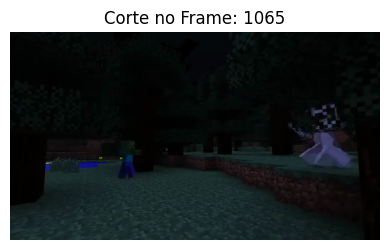

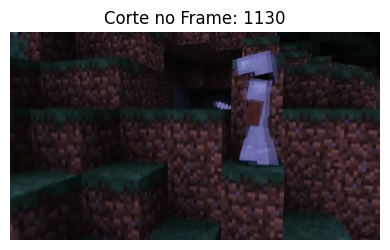

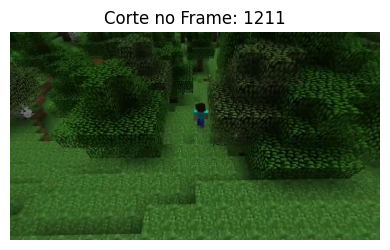

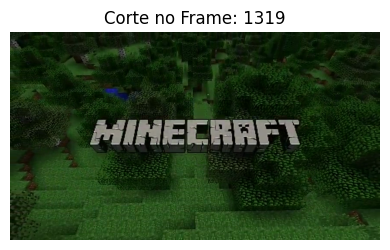

In [22]:
for idx in indices_frames_minecraft:
    visualizar_frames_ground_truth("data/videos/minecraft_trailer.mp4", idx)